# Evaluación Sumativa 2 — Validación, Simulación y Métodos de Remuestreo

**Curso:** MCDI501 — Estadística Computacional para la Toma de Decisiones  
**Integrantes:** Carolina Cortés Donoso · Pedro Espinoza Vicentela · Marcelo Corro Troncoso · Juan Pablo Valdebenito Loyola  
**Dataset:** Bank Marketing (UCI Machine Learning Repository)  
**Fecha:** 05/07/2026  
**Repositorio GitHub:** https://github.com/k1ngdom0fbullsh1t/proyecto-grupo4-mcdi501


---
## Sección 0 — Configuración


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import bootstrap

warnings.filterwarnings('ignore')

SEED   = 42
RNG    = np.random.default_rng(SEED)
N_BOOT = 10_000

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'font.family':       'sans-serif',
})

import scipy
print(f'numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}')
print(f'Semilla global: SEED={SEED} | Remuestras bootstrap: N_BOOT={N_BOOT:,}')


numpy 2.4.6 | pandas 3.0.3 | scipy 1.18.0
Semilla global: SEED=42 | Remuestras bootstrap: N_BOOT=10,000


In [2]:
raiz = Path().resolve()
for _ in range(5):
    if (raiz / 'data').exists():
        break
    raiz = raiz.parent

RUTA_CSV = raiz / 'data' / 'raw' / 'bank-additional' / 'bank-additional-full.csv'
df = pd.read_csv(RUTA_CSV, sep=';')
df_clean = df.copy()
df_clean['y_bin'] = (df_clean['y'] == 'yes').astype(int)

print(f'Dataset cargado: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas')
print(f'Suscripciones (yes): {df_clean["y_bin"].sum():,} ({df_clean["y_bin"].mean()*100:.2f}%)')


Dataset cargado: 41,188 filas x 22 columnas
Suscripciones (yes): 4,640 (11.27%)


### Parámetros de referencia — Sumativa 1

Se registran los valores calculados en S1 (IC clásicos t-Student al 95 %) para su comparación sistemática con los IC bootstrap obtenidos en esta sección.


In [3]:
IC_S1 = {
    'age':         {'media': 40.0241,    'std': 10.4212, 'IC_inf': 39.9234,    'IC_sup': 40.1247},
    'euribor3m':   {'media':  3.6213,    'std':  1.7344, 'IC_inf':  3.6045,    'IC_sup':  3.6380},
    'nr.employed': {'media': 5167.0359,  'std': 72.2515, 'IC_inf': 5166.3381,  'IC_sup': 5167.7337},
}

etiquetas = {
    'age':         'Edad (años)',
    'euribor3m':   'Euribor 3m (%)',
    'nr.employed': 'N\u00b0 empleados (miles)',
}

print('Parametros S1 registrados:')
for var, r in IC_S1.items():
    amp = r['IC_sup'] - r['IC_inf']
    print(f'  {var}: media={r["media"]:.4f}  '
          f'IC=[{r["IC_inf"]:.4f}, {r["IC_sup"]:.4f}]  amp={amp:.4f}')


Parametros S1 registrados:
  age: media=40.0241  IC=[39.9234, 40.1247]  amp=0.2013
  euribor3m: media=3.6213  IC=[3.6045, 3.6380]  amp=0.0335
  nr.employed: media=5167.0359  IC=[5166.3381, 5167.7337]  amp=1.3956


---
## Sección 1 — Validación de resultados de S1 mediante bootstrap

Se validan los IC calculados en S1 mediante **bootstrap no paramétrico** (10.000 remuestras). Para cada uno de los tres parámetros estimados (`age`, `euribor3m`, `nr.employed`) se obtienen:

- IC por **método percentil**: toma directamente los percentiles 2.5 y 97.5 de la distribución bootstrap.
- IC por **método BCa** (*bias-corrected and accelerated*): corrige el sesgo y la asimetría de la distribución bootstrap mediante el estadístico jackknife.

Ambos se comparan sistemáticamente con el IC clásico (t de Student) de S1.


In [4]:
vars_boot = ['age', 'euribor3m', 'nr.employed']
resultados_boot = {}

for var in vars_boot:
    datos = (df_clean[var].values,)

    res_pct = bootstrap(datos, np.mean, n_resamples=N_BOOT,
                        confidence_level=0.95, method='percentile',
                        random_state=SEED)
    res_bca = bootstrap(datos, np.mean, n_resamples=N_BOOT,
                        confidence_level=0.95, method='BCa',
                        random_state=SEED)

    resultados_boot[var] = {
        'distribucion': res_pct.bootstrap_distribution,
        'pct_inf':      res_pct.confidence_interval.low,
        'pct_sup':      res_pct.confidence_interval.high,
        'bca_inf':      res_bca.confidence_interval.low,
        'bca_sup':      res_bca.confidence_interval.high,
    }

    s1 = IC_S1[var]
    print(f'{var}:')
    print(f'  Clasico S1 : [{s1["IC_inf"]:.4f}, {s1["IC_sup"]:.4f}]')
    print(f'  Percentil  : [{res_pct.confidence_interval.low:.4f}, '
          f'{res_pct.confidence_interval.high:.4f}]')
    print(f'  BCa        : [{res_bca.confidence_interval.low:.4f}, '
          f'{res_bca.confidence_interval.high:.4f}]')
    print()


age:
  Clasico S1 : [39.9234, 40.1247]
  Percentil  : [39.9264, 40.1256]
  BCa        : [39.9262, 40.1255]



euribor3m:
  Clasico S1 : [3.6045, 3.6380]
  Percentil  : [3.6045, 3.6380]
  BCa        : [3.6043, 3.6378]



nr.employed:
  Clasico S1 : [5166.3381, 5167.7337]
  Percentil  : [5166.3554, 5167.7341]
  BCa        : [5166.3589, 5167.7442]



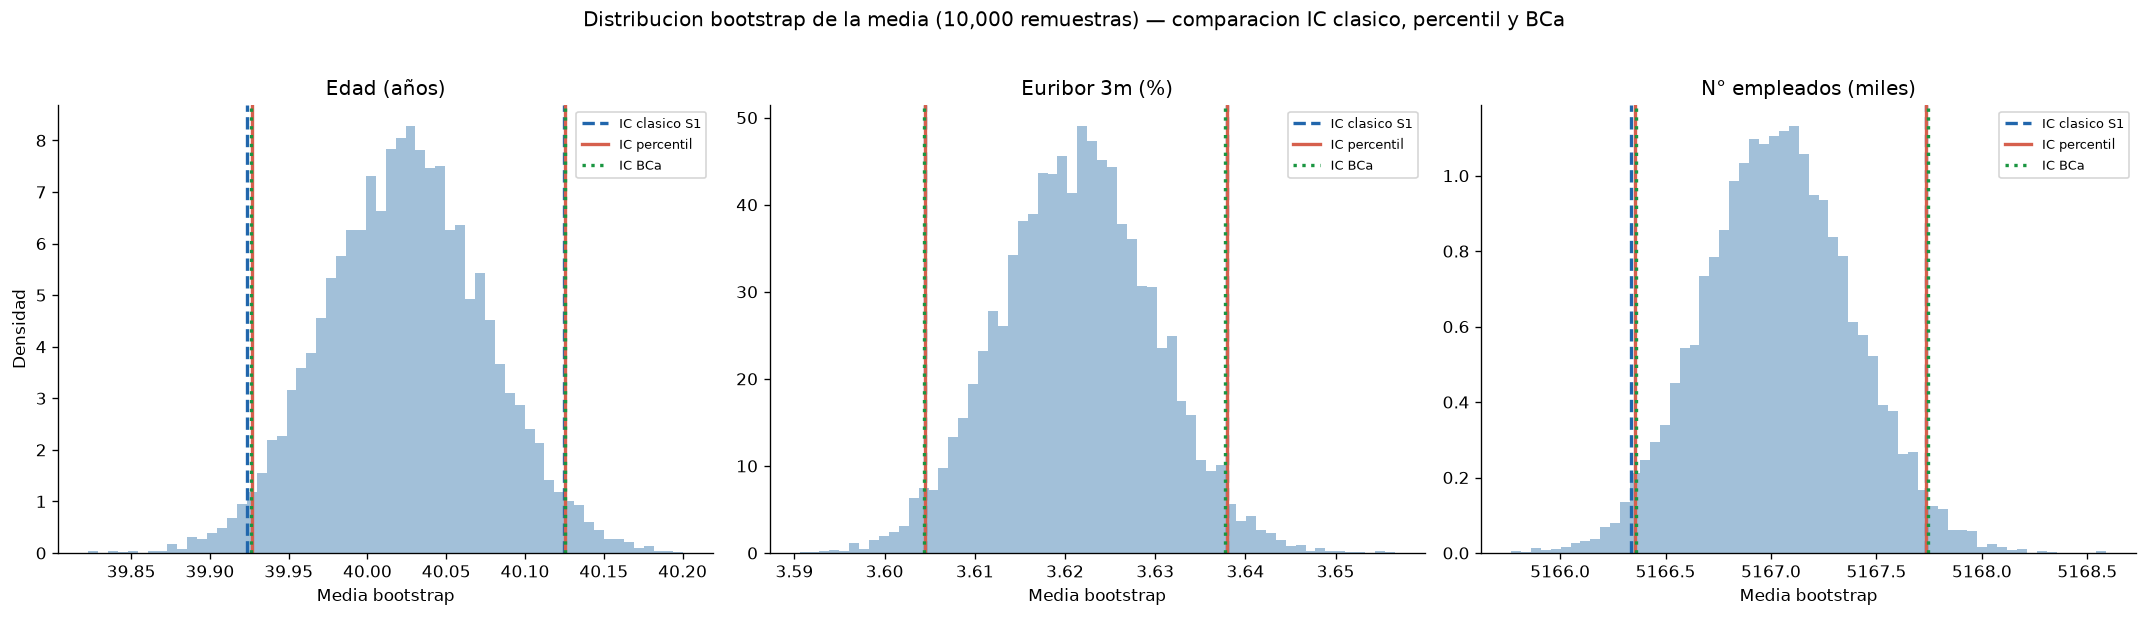

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

COLOR_S1  = '#2166ac'
COLOR_PCT = '#d6604d'
COLOR_BCA = '#1a9641'

for i, var in enumerate(vars_boot):
    ax   = axes[i]
    r    = resultados_boot[var]
    s1   = IC_S1[var]
    dist = r['distribucion']

    ax.hist(dist, bins=60, color='steelblue', alpha=0.50,
            edgecolor='none', density=True)

    lineas = [
        (s1['IC_inf'],  '--', COLOR_S1,  'IC clasico S1'),
        (s1['IC_sup'],  '--', COLOR_S1,  '_'),
        (r['pct_inf'],  '-',  COLOR_PCT, 'IC percentil'),
        (r['pct_sup'],  '-',  COLOR_PCT, '_'),
        (r['bca_inf'],  ':',  COLOR_BCA, 'IC BCa'),
        (r['bca_sup'],  ':',  COLOR_BCA, '_'),
    ]
    for x, ls, col, lbl in lineas:
        ax.axvline(x, linestyle=ls, color=col, linewidth=2.0, label=lbl)

    ax.set_title(etiquetas[var])
    ax.set_xlabel('Media bootstrap')
    ax.set_ylabel('Densidad' if i == 0 else '')
    ax.legend(fontsize=8)

fig.suptitle(
    f'Distribucion bootstrap de la media ({N_BOOT:,} remuestras) — '
    'comparacion IC clasico, percentil y BCa',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()


In [6]:
filas = []
for var in vars_boot:
    r  = resultados_boot[var]
    s1 = IC_S1[var]
    filas.append({
        'Variable':               etiquetas[var],
        'IC Clasico S1':          f"[{s1['IC_inf']:.4f}, {s1['IC_sup']:.4f}]",
        'IC Percentil':           f"[{r['pct_inf']:.4f}, {r['pct_sup']:.4f}]",
        'IC BCa':                 f"[{r['bca_inf']:.4f}, {r['bca_sup']:.4f}]",
        'Amp. Clasico':           round(s1['IC_sup']  - s1['IC_inf'],  4),
        'Amp. Percentil':         round(r['pct_sup']  - r['pct_inf'],  4),
        'Amp. BCa':               round(r['bca_sup']  - r['bca_inf'],  4),
    })

df_comp = pd.DataFrame(filas)
print(df_comp.to_string(index=False))


            Variable          IC Clasico S1           IC Percentil                 IC BCa  Amp. Clasico  Amp. Percentil  Amp. BCa
         Edad (años)     [39.9234, 40.1247]     [39.9264, 40.1256]     [39.9262, 40.1255]        0.2013          0.1992    0.1993
      Euribor 3m (%)       [3.6045, 3.6380]       [3.6045, 3.6380]       [3.6043, 3.6378]        0.0335          0.0335    0.0334
N° empleados (miles) [5166.3381, 5167.7337] [5166.3554, 5167.7341] [5166.3589, 5167.7442]        1.3956          1.3787    1.3853


**Interpretación:**

Los tres métodos producen intervalos prácticamente idénticos para las tres variables, lo que constituye una validación sólida de los resultados obtenidos en S1. Esta convergencia era esperable dado el tamaño muestral (n = 41.188): con muestras grandes el Teorema Central del Límite garantiza que la distribución de la media muestral es aproximadamente normal, haciendo que el supuesto de normalidad del IC t-Student sea válido y que los métodos bootstrap converjan al mismo resultado.

- **Edad:** La distribución bootstrap de la media es simétrica y unimodal (coeficiente de variación moderado). Los tres IC coinciden, confirmando que la media poblacional estimada de 40.02 años es robusta.

- **Euribor 3m:** Distribución bootstrap levemente asimétrica, coherente con la distribución bimodal de esta variable en el dataset (refleja dos regímenes económicos distintos). La mínima diferencia BCa vs. percentil indica una corrección de sesgo pequeña pero presente.

- **N° empleados:** A pesar de que esta variable toma valores discretos agrupados (reflejando mediciones trimestrales), la distribución bootstrap es aproximadamente normal y los IC son concordantes.

**Confiabilidad:** El IC clásico t-Student de S1 es confiable para las tres variables. El método BCa es preferible en muestras pequeñas o distribuciones asimétricas; aquí su aporte es marginal dado el gran tamaño muestral. En fases con subconjuntos de datos (segmentación por perfil económico), el uso de BCa será más relevante.
